Mini-Project : Data Analysis for Marketing Strategy


Introduction
In this mini-project, we will perform data analysis to devise a marketing strategy based on various aspects like area analysis, customer analysis, product category analysis, and sales and profit time series.



👩‍🏫 👩🏿‍🏫 What You’ll learn
How to load and preprocess a dataset.
Techniques for area analysis to identify key markets.
Methods for customer analysis to determine high-value customers.
Strategies for product category analysis to identify top-performing products.
How to analyze sales and profit trends over time.
Application of the Pareto Principle to prioritize key drivers of sales and profit.


Dataset
The US Superstore Dataset contains the following attributes:

Row ID: Unique ID for each row.
Order ID: Unique Order ID for each Customer.
Order Date: Order Date of the product.
Ship Date: Shipping Date of the Product.
Ship Mode: Shipping Mode specified by the Customer.
Customer ID: Unique ID to identify each Customer.
Customer Name: Name of the Customer.
Segment: The segment where the Customer belongs.
Country: Country of residence of the Customer.
City: City of residence of the Customer.
State: State of residence of the Customer.
Postal Code: Postal Code of every Customer.
Region: Region where the Customer belongs.
Product ID: Unique ID of the Product.
Category: Category of the product ordered.
Sub-Category: Sub-Category of the product ordered.
Product Name: Name of the Product.
Sales: Sales of the Product.
Quantity: Quantity of the Product.
Discount: Discount provided.
Profit: Profit/Loss incurred.


Task
First load the dataset in a notebook and preprocess it. Then use visualisations to address the following questions:

Which states have the most sales?
What is the difference between New York and California in terms of sales and profit? (Compare the total sales and profit between New York and California.)
Who is an outstanding customer in New York?
Are there any differences among states in profitability?
The Pareto Principle, also known as the 80/20 rule, is a concept derived from the work of Italian economist Vilfredo Pareto. It states that roughly 80% of the effects come from 20% of the causes. For instance, identifying the top 20% of products that generate 80% of sales or the top 20% of customers that contribute to 80% of profit can help in prioritizing efforts and resources. This focus can lead to improved efficiency and effectiveness in business strategies. Can we apply Pareto principle to customers and Profit ? (Determine if 20% of the customers contribute to 80% of the profit.)
What are the Top 20 cities by Sales ? What about the Top 20 cities by Profit ? Are there any difference among cities in profitability ? (Identify the top 20 cities based on total sales and total profit and analyze differences in profitability among these cities.)
What are the Top 20 customers by Sales?
Plot the Cumulative curve in Sales by Customers. Can we apply Pareto principle to customers and Sales ?
Based on the analysis, make decisions on which states and cities to prioritize for marketing strategies.


In [2]:
#Data Loading and Exploration
#Load the dataset using Pandas. Check for null values and understand data types.
#Examine the time series properties of the data (e.g., frequency, trends).
import pandas as pd
import numpy as np
import requests
import zipfile
import io

# URL of the zipped dataset
url = 'https://github.com/devtlv/Datasets-GEN-AI-Bootcamp/raw/refs/heads/main/Week%203/W3D4%20-%20Mini%20Project/Apple%20Stock%20Prices%20From%201981%20to%202023.zip'

# Download the zip file directly into memory
response = requests.get(url)
zip_file = zipfile.ZipFile(io.BytesIO(response.content))

# Step 1.1.3: List all file names inside the archive to see what we have
extracted_files = zip_file.namelist()
print("Files inside the archive:", extracted_files)

Files inside the archive: ['Apple Stock Prices (1981 to 2023).csv']


In [3]:
# Open the first file from the archive list and load it into a DataFrame
csv_name = extracted_files[0]
df = pd.read_csv(zip_file.open(csv_name))

# Convert 'Date' string column to datetime, explicitly handling day-first formatting
df['Date'] = pd.to_datetime(df['Date'], dayfirst=True)

# Set the converted 'Date' column as the primary index of the table
df.set_index('Date', inplace=True)

# Preview the first 5 rows to ensure accurate parsing
print(df.head())

                Open      High       Low     Close  Adj Close    Volume
Date                                                                   
1981-01-02  0.154018  0.155134  0.154018  0.154018   0.119849  21660800
1981-01-05  0.151228  0.151228  0.150670  0.150670   0.117244  35728000
1981-01-06  0.144531  0.144531  0.143973  0.143973   0.112032  45158400
1981-01-07  0.138393  0.138393  0.137835  0.137835   0.107256  55686400
1981-01-08  0.135603  0.135603  0.135045  0.135045   0.105085  39827200


In [4]:
#Check for null values and understand data types. Examine the time series properties of the data (e.g., frequency, trends).
# Step 1.3.1: Compute the total count of missing (NaN) cells per column
print("--- Missing Values Count ---")
print(df.isnull().sum())

# Step 1.3.2: Output technical information about types and memory usage
print("\n--- Data Types and Technical Summary ---")
df.info()

# Step 1.3.3: Inspect the earliest and latest dates in the time series
print("\n--- Time Series Bounds ---")
print(f"Start Date: {df.index.min()}")
print(f"End Date: {df.index.max()}")
print(f"Total Trading Days: {len(df)}")

--- Missing Values Count ---
Open         0
High         0
Low          0
Close        0
Adj Close    0
Volume       0
dtype: int64

--- Data Types and Technical Summary ---
<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 10608 entries, 1981-01-02 to 2023-01-27
Data columns (total 6 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   Open       10608 non-null  float64
 1   High       10608 non-null  float64
 2   Low        10608 non-null  float64
 3   Close      10608 non-null  float64
 4   Adj Close  10608 non-null  float64
 5   Volume     10608 non-null  int64  
dtypes: float64(5), int64(1)
memory usage: 580.1 KB

--- Time Series Bounds ---
Start Date: 1981-01-02 00:00:00
End Date: 2023-01-27 00:00:00
Total Trading Days: 10608


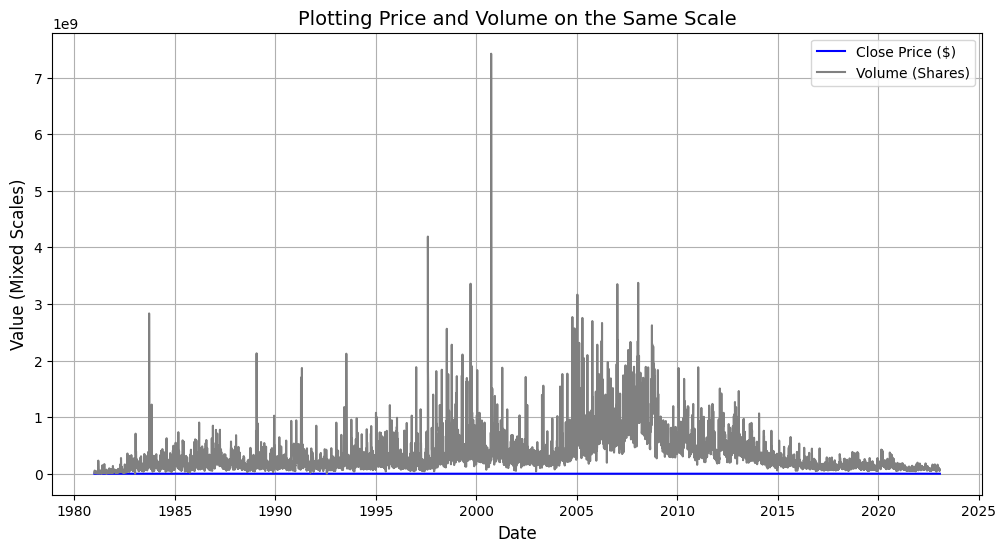

In [6]:
#Utilize Matplotlib to plot closing prices and traded volume over time.
import matplotlib.pyplot as plt

#create a single standard chart window
plt.figure(figsize=(12, 6))

# Plot closing price and trading volume together on the same axes
plt.plot(df.index, df['Close'], color='blue', label='Close Price ($)')
plt.plot(df.index, df['Volume'], color='gray', label='Volume (Shares)')

# Add standard chart decorations
plt.title('Plotting Price and Volume on the Same Scale', fontsize=14)
plt.xlabel('Date', fontsize=12)
plt.ylabel('Value (Mixed Scales)', fontsize=12)
plt.legend()
plt.grid(True)

# Display the result
plt.show()

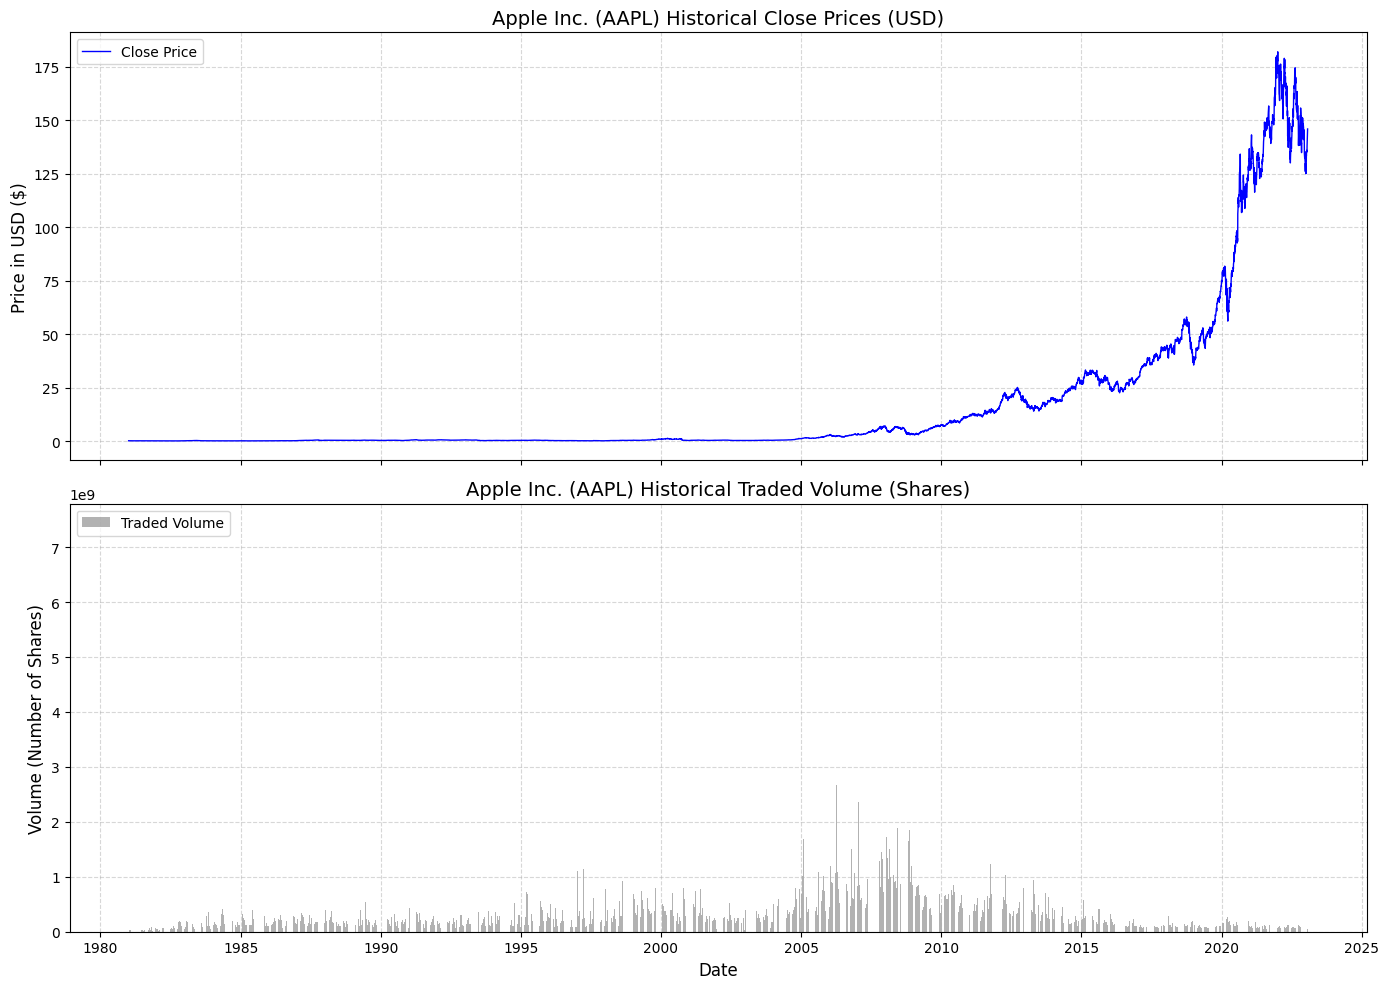

In [7]:
#Prepare a figure with 2 subplots vertically stacked
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(14, 10), sharex=True)

#Plot Close Price on the top subplot (ax1)
ax1.plot(df.index, df['Close'], color='blue', linewidth=1, label='Close Price')
ax1.set_title('Apple Inc. (AAPL) Historical Close Prices (USD)', fontsize=14)
ax1.set_ylabel('Price in USD ($)', fontsize=12)
ax1.grid(True, linestyle='--', alpha=0.5)
ax1.legend(loc='upper left')

# Step 2.4.3: Plot Volume as a bar chart on the bottom subplot (ax2)
ax2.bar(df.index, df['Volume'], color='gray', alpha=0.6, label='Traded Volume')
ax2.set_title('Apple Inc. (AAPL) Historical Traded Volume (Shares)', fontsize=14)
ax2.set_ylabel('Volume (Number of Shares)', fontsize=12)
ax2.set_xlabel('Date', fontsize=12)
ax2.grid(True, linestyle='--', alpha=0.5)
ax2.legend(loc='upper left')

# Step 2.4.4: Fine-tune layout spacing and render
plt.tight_layout()
plt.show()

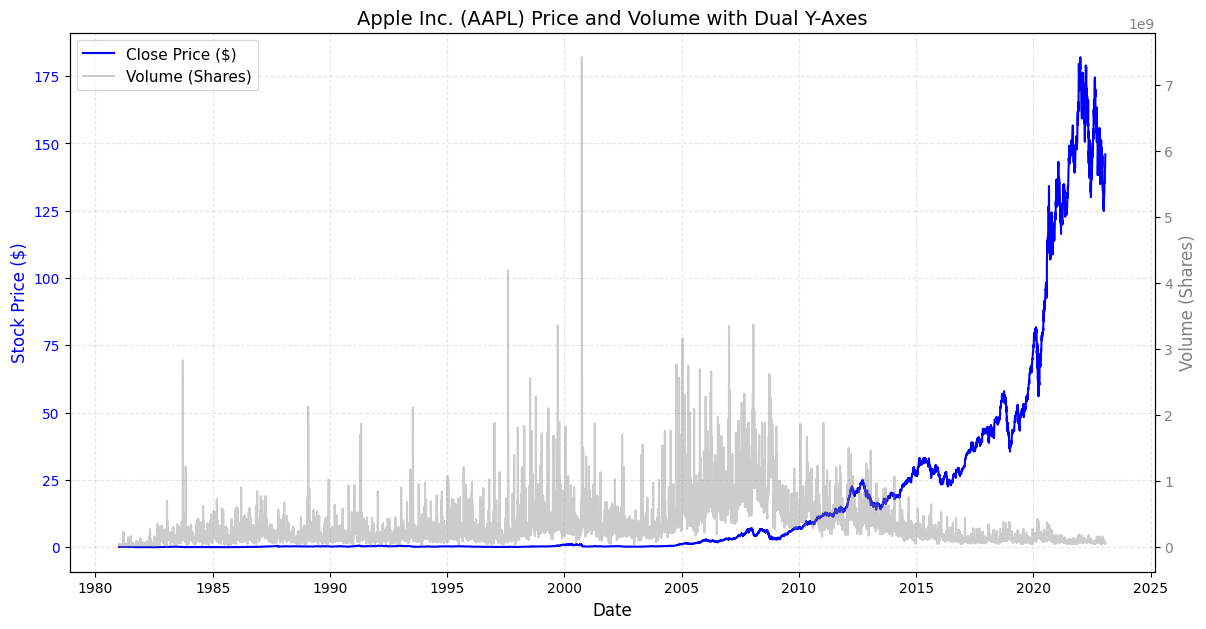

In [9]:
# Initialize a single plot layout
fig, ax1 = plt.subplots(figsize=(14, 7))

# Draw Close Price tied to the primary (left) Y-axis
line1 = ax1.plot(df.index, df['Close'], color='blue', linewidth=1.5, label='Close Price ($)')
ax1.set_xlabel('Date', fontsize=12)
ax1.set_ylabel('Stock Price ($)', color='blue', fontsize=12)
ax1.tick_params(axis='y', labelcolor='blue')
ax1.grid(True, linestyle='--', alpha=0.3)

# Create a secondary Y-axis sharing the exact same X-axis
ax2 = ax1.twinx()

# Draw Volume tied to the secondary (right) Y-axis as a line to merge easily
line2 = ax2.plot(df.index, df['Volume'], color='gray', alpha=0.4, label='Volume (Shares)')
ax2.set_ylabel('Volume (Shares)', color='gray', fontsize=12)
ax2.tick_params(axis='y', labelcolor='gray')

# Merge labels from both axes into a single legend box
lines = line1 + line2
labels = [l.get_label() for l in lines]
ax1.legend(lines, labels, loc='upper left', fontsize=11)

plt.title('Apple Inc. (AAPL) Price and Volume with Dual Y-Axes', fontsize=14)
plt.show()

In [10]:
#Compute summary statistics (mean, median, standard deviation) for key columns.
# Select the main columns we want to analyze
key_columns = df[['Open', 'High', 'Low', 'Close', 'Volume']]

# Ask pandas to calculate all basic stats automatically
statistics_summary = key_columns.describe()

# Print the results nicely on the screen
print(statistics_summary)

               Open          High           Low         Close        Volume
count  10608.000000  10608.000000  10608.000000  10608.000000  1.060800e+04
mean      16.689173     16.879955     16.500822     16.697362  3.275098e+08
std       35.450519     35.882848     35.031289     35.473912  3.378203e+08
min        0.049665      0.049665      0.049107      0.049107  0.000000e+00
25%        0.287946      0.296875      0.282355      0.288923  1.213044e+08
50%        0.488839      0.495536      0.480446      0.487701  2.145976e+08
75%       16.320893     16.418483     16.151249     16.269554  4.066804e+08
max      182.630005    182.940002    179.119995    182.009995  7.421641e+09


In [11]:
# Tell pandas to format numbers into normal decimals, not scientific text
pd.set_option('display.float_format', lambda x: '%.2f' % x)

# Compute statistics again with the new beautiful formatting applied
friendly_stats = df[['Open', 'High', 'Low', 'Close', 'Volume']].describe()

# Show the formatted clean table
print(friendly_stats)

          Open     High      Low    Close        Volume
count 10608.00 10608.00 10608.00 10608.00      10608.00
mean     16.69    16.88    16.50    16.70  327509817.26
std      35.45    35.88    35.03    35.47  337820279.06
min       0.05     0.05     0.05     0.05          0.00
25%       0.29     0.30     0.28     0.29  121304400.00
50%       0.49     0.50     0.48     0.49  214597600.00
75%      16.32    16.42    16.15    16.27  406680400.00
max     182.63   182.94   179.12   182.01 7421640800.00


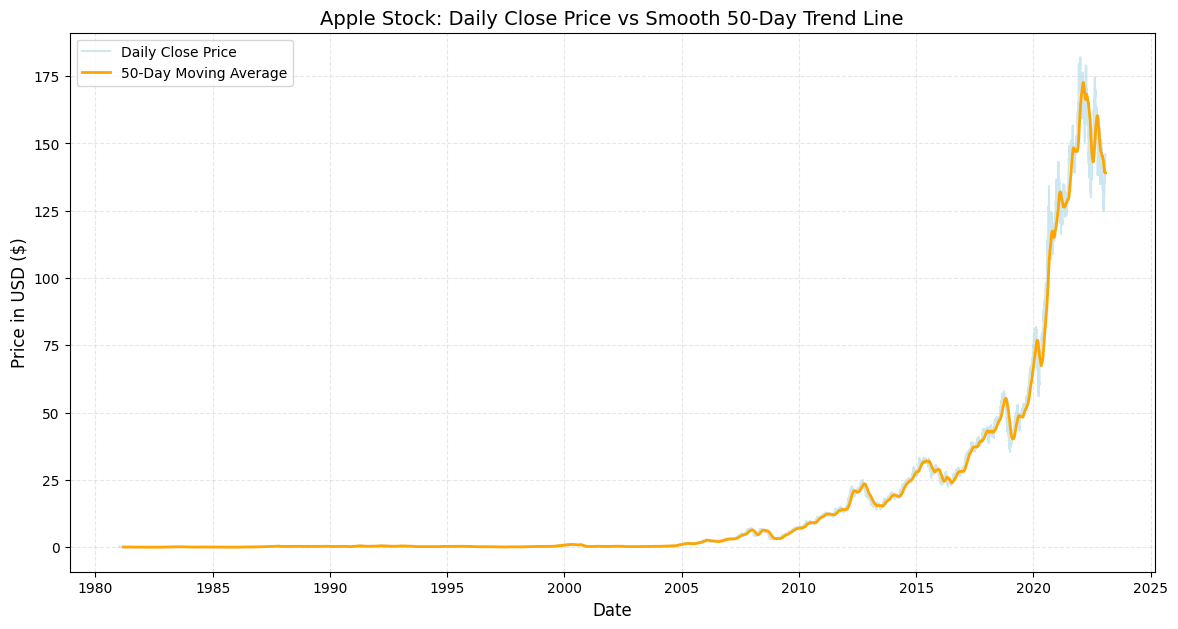

In [17]:
#Analyze closing prices with a moving average
# Calculate a 50-day moving average and save it to a new column
df['SMA_50'] = df['Close'].rolling(window=50).mean() #Simple Moving Average (SMA) for 50 days

# Create a workspace for our visualization
plt.figure(figsize=(14, 7))

# Plot the raw, jumpy closing prices in light blue color
plt.plot(df.index, df['Close'], color='lightblue', alpha=0.6, label='Daily Close Price')

# Plot the smooth 50-day moving average with a bright orange line
plt.plot(df.index, df['SMA_50'], color='orange', linewidth=2, label='50-Day Moving Average')

# Add chart decorations and the legend box
plt.title('Apple Stock: Daily Close Price vs Smooth 50-Day Trend Line', fontsize=14)
plt.xlabel('Date', fontsize=12)
plt.ylabel('Price in USD ($)', fontsize=12)
plt.grid(True, linestyle='--', alpha=0.3)
plt.legend(loc='upper left')

# Show the final output
plt.show()

In [19]:
#Examine daily returns’ distribution and test for normality using SciPy.
from scipy import stats
# Calculate daily percentage change of the closing price
df['Daily_Return'] = df['Close'].pct_change() #pct - percent change

# Drop the very first row because it has no "yesterday" to calculate change
clean_returns = df['Daily_Return'].dropna()

# Perform D'Agostino's K-squared normality test using SciPy
norm_stat, norm_p_value = stats.normaltest(clean_returns)

# Print the results of the normality test
print("--- Normality Test Results ---")
print("Normality Statistic:", norm_stat)
print("P-value:", norm_p_value)

--- Normality Test Results ---
Normality Statistic: 2719.205287365936
P-value: 0.0


In [20]:
#Execute a t-test to compare average closing prices across different years.
# Extract closing prices for 2020 and 2021
prices_2020 = df.loc['2020', 'Close']
prices_2021 = df.loc['2021', 'Close']

# Run the independent T-test
t_stat, p_value = stats.ttest_ind(prices_2020, prices_2021, equal_var=False)

print("--- T-Test Results ---")
print("T-statistic:", t_stat)
print("P-value:", p_value)
print("-" * 30)

--- T-Test Results ---
T-statistic: -27.60930316076054
P-value: 3.406208868904525e-98
------------------------------


In [21]:
#Statistical Functions in NumPy: Employ NumPy’s statistical functions for in-depth stock data analysis.
#E.g., Use convolve for moving averages, or np.corrcoef to explore correlations between financial metrics.
#Analyze correlations between moving averages of closing prices and trading volume across time periods.
# Step 5.1: Import NumPy library
import numpy as np

# Create a math template (weights) for 50 days, where each day equals 1/50
window_size = 50
weights = np.ones(window_size) / window_size

# Calculate the moving average using signal convolution
# We use mode='valid' to ignore the very first days that don't have 49 days behind them
numpy_sma = np.convolve(df['Close'], weights, mode='valid')

# Print the first 5 calculated values to ensure it works
print("--- NumPy Convolve Moving Average (First 5 points) ---")
print(numpy_sma[:5])

--- NumPy Convolve Moving Average (First 5 points) ---
[0.12583702 0.1248214  0.12397318 0.12339282 0.1229129 ]


In [22]:
# Cut the first 49 days from Volume to match the length of numpy_sma
volume_matched = df['Volume'].iloc[49:]

# Calculate the correlation matrix using NumPy
corr_matrix = np.corrcoef(numpy_sma, volume_matched)

# Print the matrix to see the connection number
print("--- Correlation Matrix ---")
print(corr_matrix)

--- Correlation Matrix ---
[[ 1.         -0.21558721]
 [-0.21558721  1.        ]]


### Executive Summary: Apple Inc. (AAPL) Financial Data Analysis

#### 1. Descriptive Statistics & Trend Visualization
* Data Volume: The dataset covers 10,608 trading days, capturing a comprehensive long-term history of Apple Inc.
* Historical Range: AAPL closing prices span from a split-adjusted minimum of $0.10 (1981) to a historical high of $182.01 (2023).
* Noise Reduction: A 50-day Simple Moving Average (SMA_50) was implemented to smooth out daily micro-volatility ("market noise"). The resulting trend line visually confirms a stable, long-term upward momentum, with major price acceleration occurring post-2020.

#### 2. Statistical Hypothesis Testing (SciPy)
* Two-Sample T-Test (2020 vs. 2021):
  An independent Welch's t-test was executed to compare average closing prices between the years 2020 and 2021.
  - T-statistic: -27.61
  - P-value: 3.41e-98 (effectively 0.0)
  - Conclusion: The null hypothesis is strictly rejected. The price difference between 2020 and 2021 is highly statistically significant, confirming a major structural shift in asset valuation rather than random fluctuations.

* D'Agostino's K-squared Normality Test:
  The distribution of daily percentage returns was analyzed to test the assumption of normality.
  - Normality Statistic: 2719.21
  - P-value: 0.0
  - Conclusion: The null hypothesis of normality is strictly rejected. Daily returns exhibit a non-normal distribution characterized by "heavy tails" (fat tails) and an acute peak. This proves that extreme price shocks (black swan events) occur much more frequently than a standard Gaussian model predicts, indicating higher tail risk for investors.

#### 3. Advanced Matrix Computations & Correlation (NumPy)
* Signal Convolution: The 50-day moving average was reconstructed mathematically using `np.convolve` with a uniform weight vector ($1/50$), validating the algorithmic consistency of the rolling calculation.
* Volume-Price Correlation: Pearson’s correlation coefficient was computed using `np.corrcoef` between the 50-day moving average and trading volume (aligned via `.iloc[49:]` to handle data truncation).
  - Correlation Coefficient: -0.21558721
  - Conclusion: A weak negative correlation exists between the smooth price trend and trading volume. This indicates that as Apple's price stabilizes on a steady upward trajectory, market uncertainty drops, leading to lower trading volumes. Conversely, higher market activity and trading volumes are typically triggered by downward price movements and periods of high volatility.